# Writing a Transformer as One Expression

`Transformer.ipynb` builds the same model a piece at a time and checks each
piece. This notebook writes it as a single expression, to show how short the
whole architecture becomes once the three composition operators do the wiring.
Every block is named and coloured, and the diagram below is drawn from the
expression alone.

*Written by Claude Opus 5 (1M context) at reasoning effort high, 2026-09-20.*

In [1]:
import construction_helpers as ch  # noqa: F401 - operator overloads
import data_structure.Category as cat
import data_structure.Operators as ops

import notebooks.display.notebook_diagrams as notebook_diagrams

DIAGRAMS = notebook_diagrams.DiagramSettings(
    mode=notebook_diagrams.DiagramMode.INLINE, width=900)

## The model

`@` composes sequentially, `*` places two morphisms side by side, and a tuple
of indices in front of a morphism is a rearrangement that copies, drops and
permutes the wires. `cat.Block.template` groups a morphism under a title, and a
`repetition` on a block states how many times its body runs.

The last two statements are the model: one layer built from the two residual
sublayers, then the embedding, six of those layers, and the projection onto the
vocabulary.

The transformer. The repeated layer is drawn once, with the count of repetitions on its box.


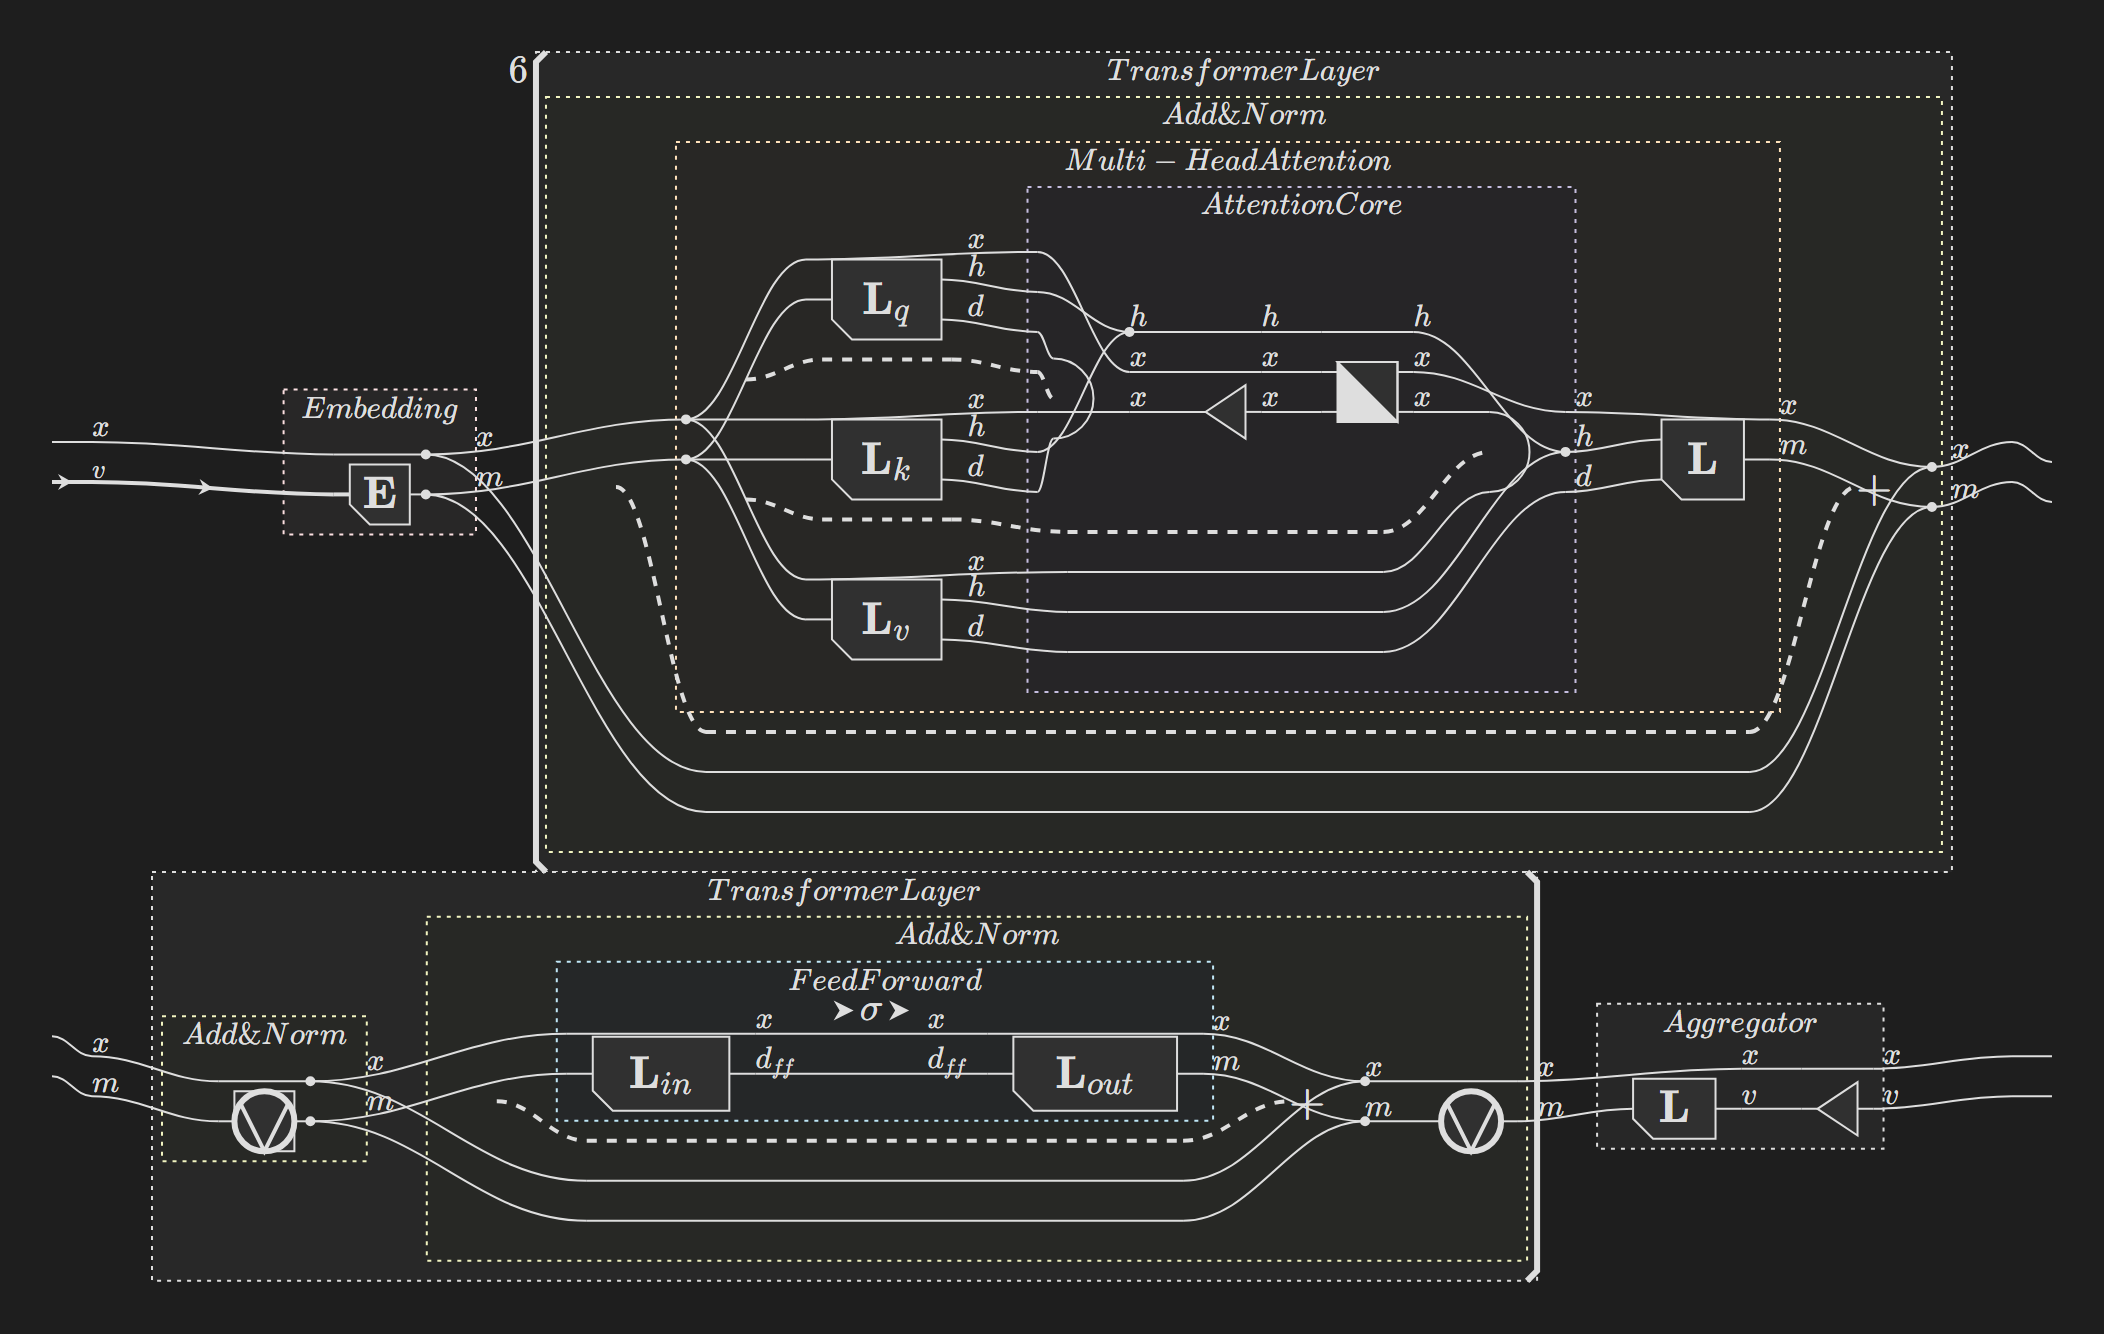

In [2]:
multihead_attention_core = cat.Block.template(
      ops.Einops.template('q h d, x h d -> h q x')
    @ ops.SoftMax.template()
    @ ops.WeightedTriangularLower.template()
    @ ops.Einops.template('h q x, x h d -> q h d'),
    title='Attention Core',
    fill_color='#C5BEDF')
attention_block = cat.Block.template(
    (0, 0, 0)
    @ (ops.Linear.template('m', 2, 'L_q')
     * ops.Linear.template('m', 2, 'L_k')
     * ops.Linear.template('m', 2, 'L_v'))
    @ multihead_attention_core
    @ ops.Linear.template(2, 'm'),
    title='Multi-Head Attention',
    fill_color='#FFE2BB')
feed_forward = cat.Block.template(
    ops.Linear.template(1, ('d_ff',), 'L_in')
    @ ops.Elementwise.template()
    @ ops.Linear.template(('d_ff',), 1, 'L_out'),
    title='Feed Forward',
    fill_color='#C1E8F7')
embedding = cat.Block.template(
    ops.Embedding.template('v'),
    title='Embedding',
    fill_color='#FCE0E1')
aggregator = cat.Block.template(
    ops.Linear.template(1, 'v') @ ops.SoftMax.template(),
    title='Aggregator',
    fill_color='#DBDFEF')


def residual[B: cat.Datatype, A: cat.Axis](
    target: cat.BroadcastedCategory[B, A],
) -> cat.Block[cat.Array[B, A], cat.BroadcastedCategory[B, A]]:
    return cat.Block.template(
          (0, 0)
        @ target
        @ ops.AdditionOp.template()
        @ ops.Normalize.template(),
        title='Add \\& Norm',
        fill_color='#F1F4C1')


transformer_layer = residual(attention_block) @ residual(feed_forward)
transformer = (
    embedding
    @ cat.Block.template(
        transformer_layer,
        repetition=6,
        title='Transformer Layer',
        fill_color='#F3F3F4')
    @ aggregator)

indices, = transformer.dom()
distribution, = transformer.cod()
assert isinstance(indices.datatype, cat.Natural), (
    'the model reads token indices, which are natural numbers')
assert len(distribution.shape()) == 2, (
    'the model writes one array of positions by vocabulary entries')
assert transformer_layer.dom() == transformer_layer.cod(), (
    'a layer returns the object it was given, which is what lets it repeat')
await notebook_diagrams.show_diagram(
    transformer,
    'The transformer. The repeated layer is drawn once, with the count of '
    'repetitions on its box.',
    settings=DIAGRAMS)